# PYORPS Feasibility Routing: User-Weighted Multi-Objective Optimization

This example introduces the **feasibility objective** — routing that minimizes a
user-weighted combination of criteria instead of monetary cost alone:

$$F(\text{path}) = \sum_k w_k \cdot M_k(\text{path})$$

| Metric $M_k$ | Kind | Meaning |
|---|---|---|
| `cost` | cell | construction cost (EUR/m) — the default objective |
| `length` | implicit | route length in meters (3D when a DEM is present) |
| `gradient` | **edge** | along-route grade, computed **inside the search kernels** from the DEM |
| `landscape`, `permit`, ... | cell | any per-meter intensity you define in the cost assumptions |
| `terrain_slope` | cell | cross-slope constructability, derived from the DEM |

Two rules to remember:

1. **Everything acts during the search** — nothing about the route choice is post-processed.
2. **With a DEM, slope is always respected in the path length** (3D stretch — geometry, not
   an option). *How* slope additionally contributes to the feasibility is configurable:
   linear, quadratic, exponential responses — additive and/or multiplicative.

Datasets: the OSMSES 2026 tutorial sample raster, and — when available — the 3D case-study
data of `constrained_routing_3d.py` (Biebertal DGM1 + distribution-grid cost raster) with
the **same source–target pairs** as the constrained example.

> Design details: `docs/superpowers/plans/2026-08-04-feasibility-multi-objective-routing.md`

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import rasterio
from matplotlib.colors import LightSource
from rasterio.transform import from_origin

from pyorps import PathFinder, Objective

plt.rcParams["figure.dpi"] = 100


def plot_cost_raster(ax, data, title="", cmap="viridis"):
    """Cost raster display in the style of the OSMSES tutorial."""
    shown = np.where(data == 65535, np.nan, data.astype(float))
    im = ax.imshow(shown, cmap=cmap)
    ax.set_title(title)
    plt.colorbar(im, ax=ax, shrink=0.75, label="cost / weight")


def plot_routes_on_dem(ax, dem, transform, routes, title=""):
    """Hillshaded DEM + contour lines + route geometries."""
    ls = LightSource(azdeg=315, altdeg=45)
    extent = (transform.c, transform.c + transform.a * dem.shape[1],
              transform.f + transform.e * dem.shape[0], transform.f)
    ax.imshow(ls.hillshade(dem.astype(float), vert_exag=2), cmap="gray",
              extent=extent, alpha=0.7)
    xs = np.linspace(extent[0], extent[1], dem.shape[1])
    ys = np.linspace(extent[3], extent[2], dem.shape[0])
    cs = ax.contour(xs, ys, dem, levels=12, colors="saddlebrown",
                    linewidths=0.6, alpha=0.8)
    ax.clabel(cs, inline=True, fontsize=7, fmt="%.0f m")
    for label, (path, color) in routes.items():
        coords = np.asarray(path.path_coords)
        ax.plot(coords[:, 0], coords[:, 1], color=color, lw=2.2, label=label)
        ax.plot(*coords[0], "o", color="green", ms=9, zorder=5)
        ax.plot(*coords[-1], "X", color="red", ms=10, zorder=5)
    ax.set_title(title)
    ax.legend(loc="upper right")
    ax.set_aspect("equal")

---
# Part 1: Objectives on the Tutorial Sample Raster

Same dataset and source–target pair as the OSMSES tutorial's minimal example.
`objective={"cost": 1.0}` reproduces the classic route **byte-identically** (zero-copy
fast path); switching the objective re-runs only the combine step — no graph rebuild
on the raster-direct backends.

objective       length   detour
cheapest        1192 m    1.19x
shortest        1081 m    1.08x


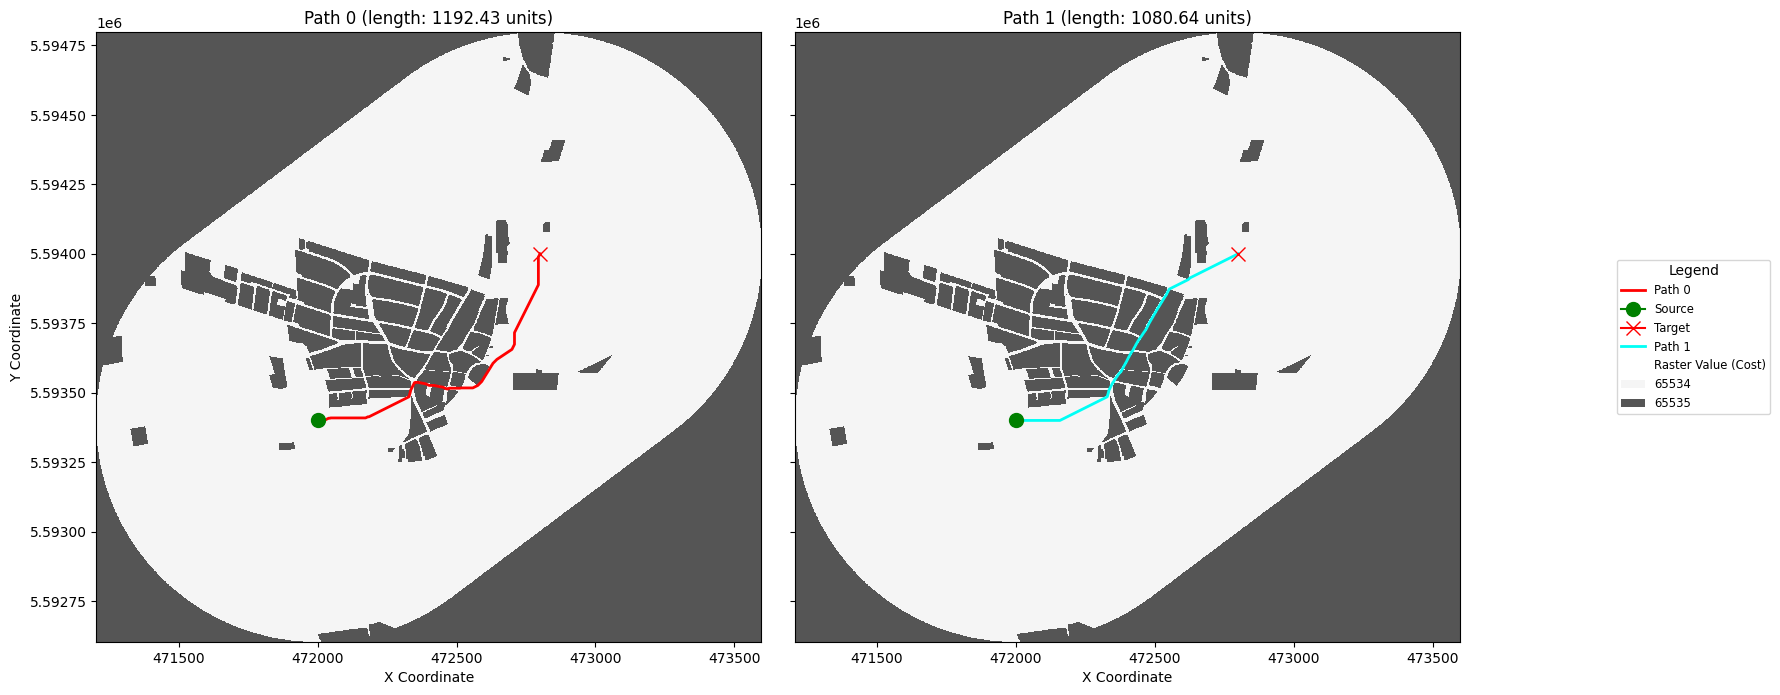

<Figure size 640x480 with 0 Axes>

In [2]:
source = (472000, 5593400)
target = (472800, 5594000)
raster_path = "./data/raster/sample_raster.tiff"

pf = PathFinder(dataset_source=raster_path, source_coords=source,
                target_coords=target, objective={"cost": 1.0})

cheapest = pf.find_route()
shortest = pf.find_route(objective={"length": 1.0})   # per-call override

print(f"{'objective':<12} {'length':>9} {'detour':>8}")
for name, p in [("cheapest", cheapest), ("shortest", shortest)]:
    print(f"{name:<12} {p.total_length:>7.0f} m "
          f"{p.total_length / p.euclidean_distance:>7.2f}x")

pf.plot_paths()
plt.suptitle("Cheapest (id 0) vs. shortest (id 1) on the tutorial raster")
plt.tight_layout()
plt.show()

---
# Part 2: Multi-Metric Cost Assumptions — the Cheap-but-Protected Corridor

Cost-assumption leaves may carry **several named metrics**. The scenario below is
inexpressible with a single cost number: a corridor that is *cheap to build* but runs
through *protected landscape*. The route flips as soon as the landscape weight makes
protection matter.

> With live data, the `landscape` values would come from the same WFS layers the OSMSES
> tutorial uses (e.g. LUBW *Landschaftsschutzgebiete*) — here we keep the notebook
> self-contained with an in-memory dataset.

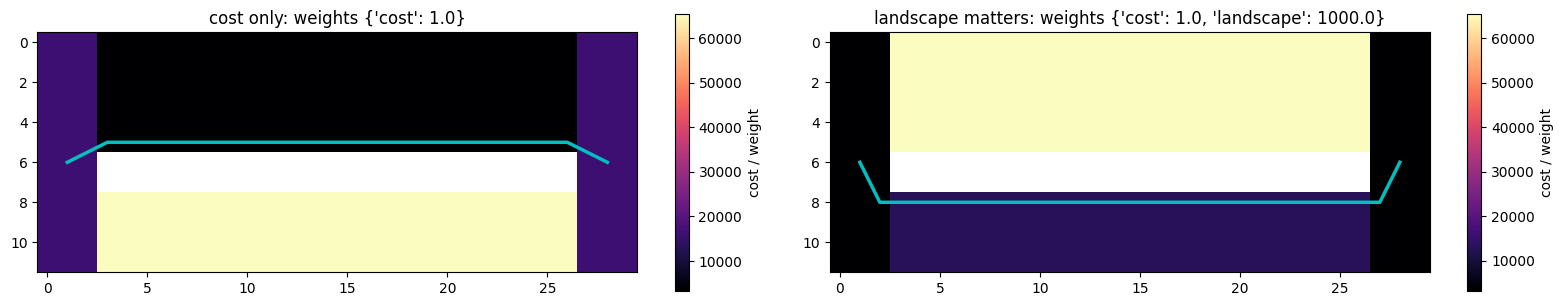

cost only            length  27.5 m | objective spec: {'cost': 1.0}
landscape matters    length  29.5 m | objective spec: {'cost': 1.0, 'landscape': 1000.0}

Stack layers: ['cost', 'landscape']


In [3]:
import geopandas as gpd
from shapely.geometry import Polygon

assumptions = {"landuse": {
    "neutral":         {"cost": 50.0,  "landscape": 0.0},
    "protected_cheap": {"cost": 10.0,  "landscape": 1.0},   # cheap, protected
    "open_expensive":  {"cost": 200.0, "landscape": 0.0},   # expensive, open
    "barrier": 65535,                                        # forbidden everywhere
}}
polys = {
    "neutral": [Polygon([(0, 0), (3, 0), (3, 12), (0, 12)]),
                Polygon([(27, 0), (30, 0), (30, 12), (27, 12)])],
    "protected_cheap": [Polygon([(3, 6), (27, 6), (27, 12), (3, 12)])],
    "open_expensive":  [Polygon([(3, 0), (27, 0), (27, 4), (3, 4)])],
    "barrier":         [Polygon([(3, 4), (27, 4), (27, 6), (3, 6)])],
}
records = [(k, g) for k, geoms in polys.items() for g in geoms]
gdf = gpd.GeoDataFrame({"landuse": [r[0] for r in records],
                        "geometry": [r[1] for r in records]}, crs="EPSG:25832")

variants = {}
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
for ax, (name, weights) in zip(axes, {
        "cost only":        {"cost": 1.0},
        "landscape matters": {"cost": 1.0, "landscape": 1000.0}}.items()):
    f = PathFinder(dataset_source=gdf, source_coords=(1.5, 6.0),
                   target_coords=(28.5, 6.0), search_space_buffer_m=50,
                   cost_assumptions=assumptions, objective=weights,
                   resolution_in_m=1.0)
    p = f.find_route()
    variants[name] = (f, p)
    plot_cost_raster(ax, f.raster_handler.data[0],
                     title=f"{name}: weights {weights}", cmap="magma")
    idx = np.array(p.path_indices)
    cols = f.raster_handler.data[0].shape[1]
    ax.plot(idx % cols, idx // cols, "c-", lw=2.5)
plt.tight_layout()
plt.show()

for name, (f, p) in variants.items():
    print(f"{name:<20} length {p.total_length:5.1f} m | "
          f"objective spec: {p.objective_spec['weights']}")
print("\nStack layers:", variants["cost only"][0].metric_stack.layer_names)

---
# Part 3: Routing Around a Hill on the Contour Line

The centerpiece. The along-route **gradient is an edge metric**: on a hillside every
*cell* has the same steepness, but a step *along the contour* is level while a step up
the fall line is steep — only the search kernels can tell the difference (they compute
$s = |\Delta h| / d_{horiz}$ per relaxed edge and look the response up in the
slope-LUT pair).

Four objectives on the same Gaussian hill:

| # | Objective | Expectation |
|---|---|---|
| 1 | `cost`, **no DEM** | straight over the summit |
| 2 | `cost` **+ DEM** | 3D stretch (always on) sidesteps the steep summit |
| 3 | `gradient`-weighted | **follows the contour line around the hill** |
| 4 | `max_gradient_pct=25` | hard grade limit — stays below the steep flanks |

In [4]:
Nr, Nc = 240, 360
yy, xx = np.mgrid[0:Nr, 0:Nc]
dem_hill = (55.0 * np.exp(-(((xx - 180) / 60.0) ** 2
                            + ((yy - 120) / 45.0) ** 2))).astype(np.float32)
W_uniform = np.full((Nr, Nc), 100, dtype=np.uint16)
T = from_origin(0.0, float(Nr), 1.0, 1.0)   # 1 m cells

common = dict(dataset_source=W_uniform, crs="EPSG:25832", transform=T,
              source_coords=(20.5, 120.5), target_coords=(339.5, 120.5),
              search_space_buffer_m=400, graph_api="cython")

runs = {
    "1 no DEM (straight)":  PathFinder(objective={"cost": 1.0}, **common),
    "2 3D stretch only":    PathFinder(objective={"cost": 1.0},
                                       dem=dem_hill, **common),
    "3 gradient-weighted":  PathFinder(objective={"gradient": 12.0,
                                                  "length": 1.0},
                                       dem=dem_hill, **common),
    "4 max gradient 25%":   PathFinder(objective={"cost": 1.0},
                                       gradient_options={"max_gradient_pct": 25.0},
                                       dem=dem_hill, **common),
}

results = {name: f.find_route() for name, f in runs.items()}

print(f"{'variant':<24} {'length':>9} {'highest point on route':>24}")
for name, p in results.items():
    idx = np.array(p.path_indices)
    h = dem_hill[idx // Nc, idx % Nc]
    print(f"{name:<24} {p.total_length:>7.1f} m {h.max():>20.1f} m")

variant                     length   highest point on route
1 no DEM (straight)        319.0 m                 55.0 m
2 3D stretch only          342.6 m                 27.0 m
3 gradient-weighted        415.1 m                  0.2 m
4 max gradient 25%         343.7 m                 19.3 m


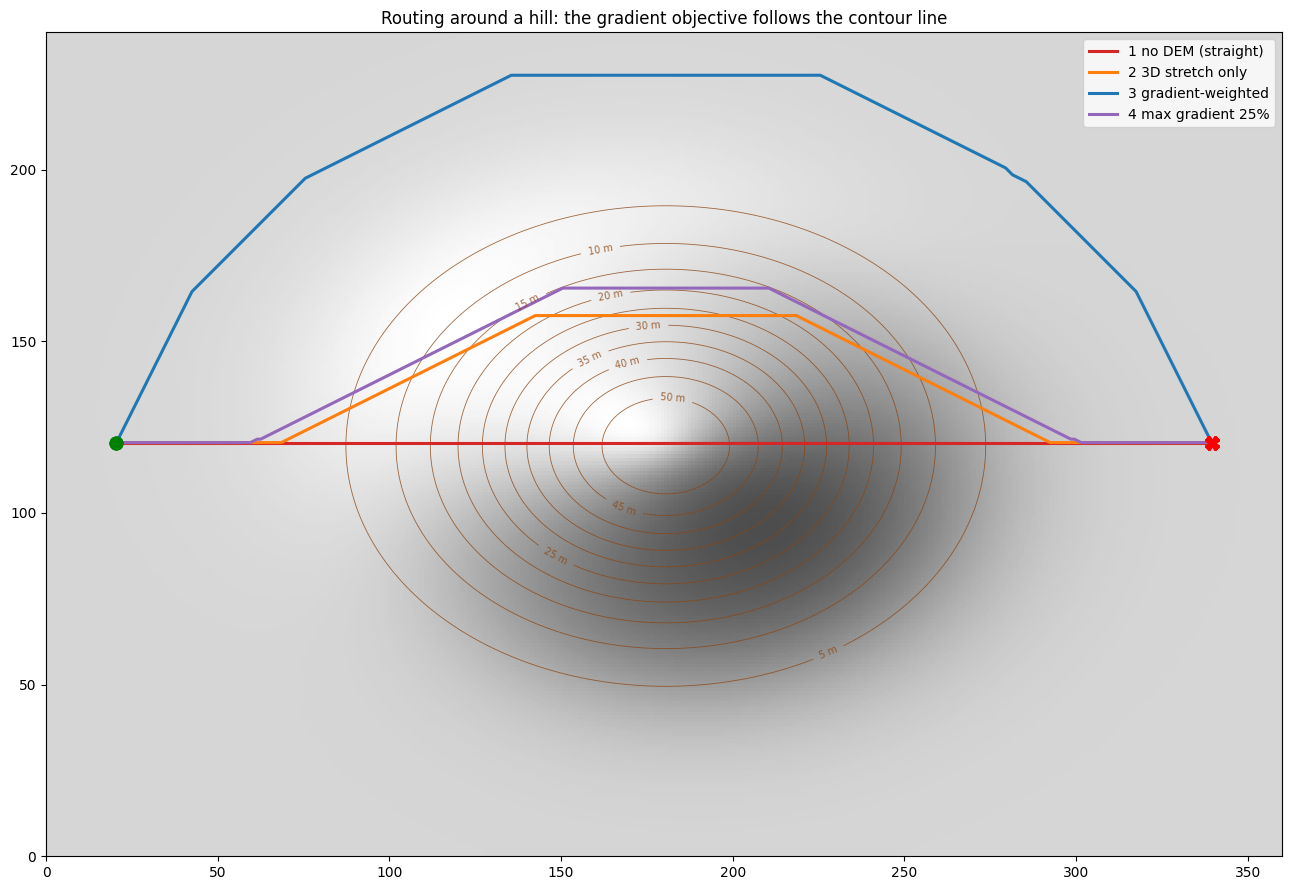

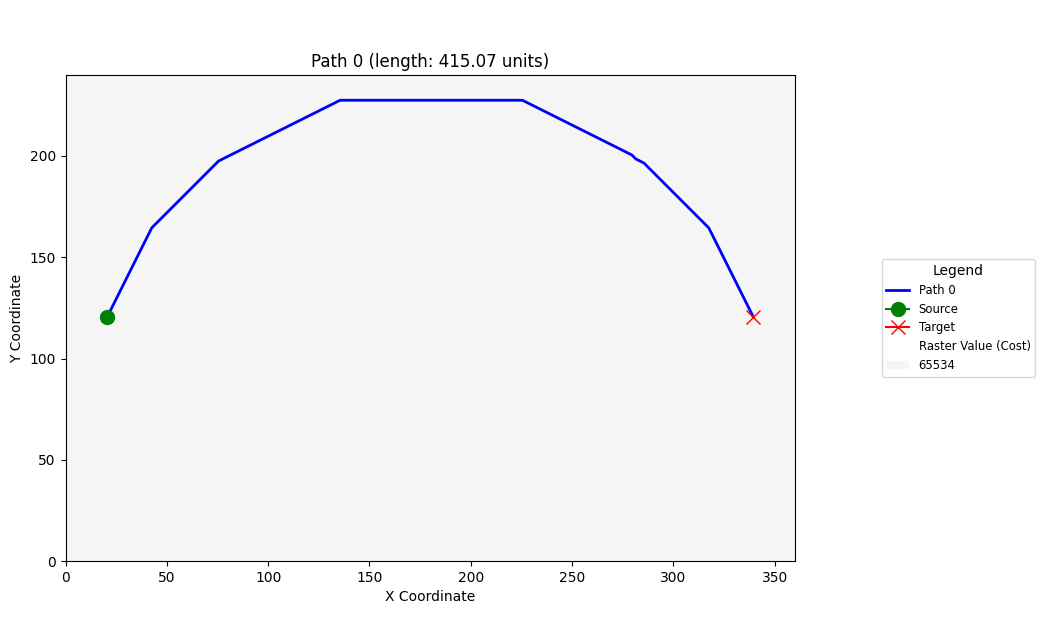

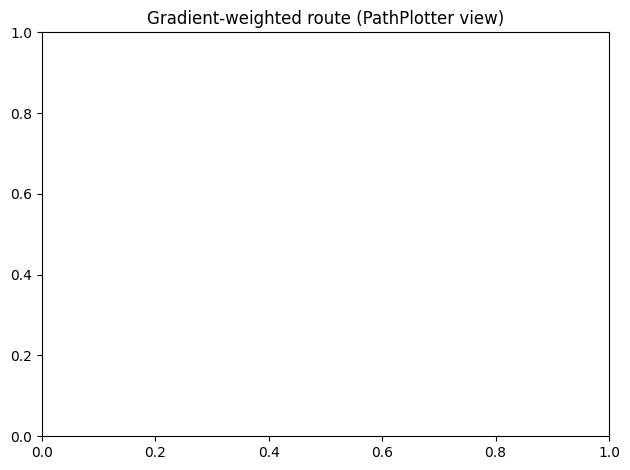

In [5]:
fig, ax = plt.subplots(figsize=(14, 9))
colors = {"1 no DEM (straight)": "tab:red",
          "2 3D stretch only": "tab:orange",
          "3 gradient-weighted": "tab:blue",
          "4 max gradient 25%": "tab:purple"}
plot_routes_on_dem(
    ax, dem_hill, T,
    {n: (p, colors[n]) for n, p in results.items()},
    title="Routing around a hill: the gradient objective follows the contour line",
)
plt.tight_layout()
plt.show()

# The built-in visualization works as usual for any variant:
runs["3 gradient-weighted"].plot_paths()
plt.title("Gradient-weighted route (PathPlotter view)")
plt.tight_layout()
plt.show()

---
# Part 4: Biebertal Case Study — Real Terrain, Constrained-Example Pairs

The same datasets as `constrained_routing_3d.py` (and the 3D case studies): the
distribution-grid cost raster and the **Biebertal DGM1** elevation model, with the
**identical source–target pairs** (Route 1 short / Route 2 forest). The gradient
objective makes underground-cable routes hug the valley contours instead of cutting
across the slopes.

*The cells below run only when the case-study files are present on this machine.*

In [6]:
RASTER_3D = r"./data/raster/modified_raster_for_distribution_grid_planning.tiff"
DGM1_PATH = (r"C:\Users\mhnn82\Documents\2_python_projects\pyorps"
             r"\case_studies\3d\Biebertal - DGM1\dgm1_merged.tif")

# Same pairs as constrained_routing_3d.py
ROUTES_3D = {
    "Route 1 (short)":  {"source": (473609, 5607305),
                         "target": (474443, 5606872), "buffer": 500},
    "Route 2 (forest)": {"source": (473000, 5608000),
                         "target": (475500, 5606000), "buffer": 1000},
}

HAVE_CASE_STUDY = os.path.exists(RASTER_3D) and os.path.exists(DGM1_PATH)
print("Case-study data available:", HAVE_CASE_STUDY)
if not HAVE_CASE_STUDY:
    print("-> place the files at the paths above to run this part "
          "(see examples/constrained_routing_3d.py)")

Case-study data available: False
-> place the files at the paths above to run this part (see examples/constrained_routing_3d.py)


In [7]:
if HAVE_CASE_STUDY:
    for route_name, cfg in ROUTES_3D.items():
        shared = dict(dataset_source=RASTER_3D, dem=DGM1_PATH,
                      source_coords=cfg["source"], target_coords=cfg["target"],
                      search_space_buffer_m=cfg["buffer"], graph_api="cython")

        cheap = PathFinder(objective={"cost": 1.0}, **shared).find_route()
        gentle_pf = PathFinder(
            objective={"cost": 1.0, "gradient": 60.0},
            gradient_options={"additive": "quadratic"}, **shared)
        gentle = gentle_pf.find_route()

        print(f"\n{route_name}")
        print(f"  cheapest : {cheap.total_length:8.1f} m")
        print(f"  gentlest : {gentle.total_length:8.1f} m "
              f"(+{gentle.total_length / cheap.total_length - 1:.1%} length "
              f"for less grade)")

        # DGM window around the route for the contour background
        handler = gentle_pf.dem_raster_handler
        dem_win = handler.data[0] if handler.data.ndim > 2 else handler.data
        fig, ax = plt.subplots(figsize=(13, 9))
        plot_routes_on_dem(
            ax, dem_win, handler.window_transform,
            {"cheapest": (cheap, "tab:red"),
             "gradient-weighted": (gentle, "tab:blue")},
            title=f"{route_name}: contour-aware routing on the Biebertal DGM1",
        )
        plt.tight_layout()
        plt.show()

---
# Part 5: Cross-Slope as a Cell Metric (`terrain_slope`)

Along-route **gradient** (edge metric) and cross-slope **constructability** (cell
metric) are different quantities: a side-hill trench along the contour is dead level
*along the route* but still hard to *build*. `metric_layers` derives `terrain_slope`
from the DEM, weights it like any metric — and `hard_max` turns it into an exclusion
zone.

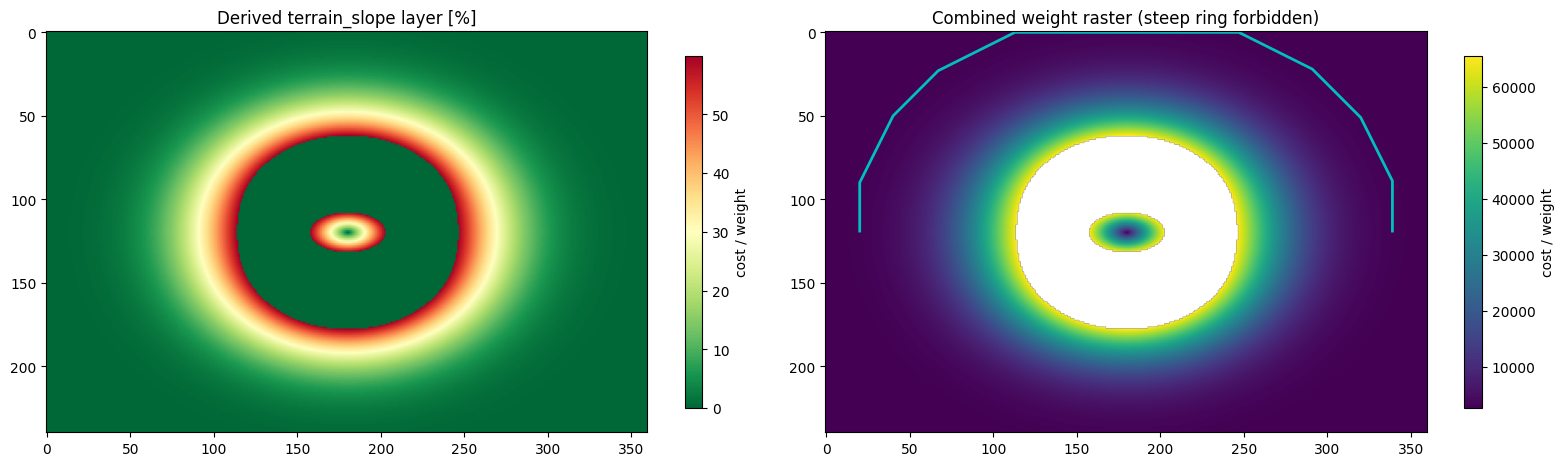

Route length: 460.0 m | layers: ['cost', 'terrain_slope']


In [8]:
import geopandas as gpd
from shapely.geometry import Polygon

area = gpd.GeoDataFrame(
    {"landuse": ["field"],
     "geometry": [Polygon([(0, 0), (Nc, 0), (Nc, Nr), (0, Nr)])]},
    crs="EPSG:25832")

f_slope = PathFinder(
    dataset_source=area,
    source_coords=(20.5, 120.5), target_coords=(339.5, 120.5),
    search_space_buffer_m=400, graph_api="cython",
    cost_assumptions={"landuse": {"field": 100}},
    dem=dem_hill, transform=T,
    objective={"cost": 1.0, "terrain_slope": 40.0},
    metric_layers={"terrain_slope": {"derive": "slope_from_dem",
                                     "hard_max": 60.0}},
    resolution_in_m=1.0,
)
p_slope = f_slope.find_route()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
plot_cost_raster(axes[0], f_slope.metric_stack["terrain_slope"],
                 title="Derived terrain_slope layer [%]", cmap="RdYlGn_r")
plot_cost_raster(axes[1], f_slope.raster_handler.data[0],
                 title="Combined weight raster (steep ring forbidden)")
idx = np.array(p_slope.path_indices)
cols = f_slope.raster_handler.data[0].shape[1]
axes[1].plot(idx % cols, idx // cols, "c-", lw=2)
plt.tight_layout()
plt.show()
print(f"Route length: {p_slope.total_length:.1f} m | "
      f"layers: {f_slope.metric_stack.layer_names}")

---
# Part 6: Route Ensembles & the Price of a Policy

`find_route_ensemble` routes the same pair under several objectives (sequentially;
on the raster-direct backends each variant costs only combine + search). Every path
carries **all** metrics, so the comparison table is free — and `pareto_front` filters
the non-dominated variants. `compare_optimal` prices the active policy against
single-metric optima: *"the gentle route costs +X EUR and saves Y grade exposure."*


In [9]:
pf_ens = PathFinder(objective={"cost": 1.0}, dem=dem_hill, **common)

ensemble = pf_ens.find_route_ensemble({
    "cheapest": {"cost": 1.0},
    "shortest": {"length": 1.0},
    "gentlest": {"gradient": 12.0, "length": 1.0},
    "balanced": {"cost": 1.0, "gradient": 4.0},
})
table = ensemble.to_dataframe()
display(table[[c for c in ("feasibility", "cost", "length", "gradient",
                           "max_gradient_pct", "same_route_as")
               if c in table.columns]].round(1))

front = ensemble.pareto_front(["cost", "gradient"])
print("Pareto front (cost vs gradient):", front.names)

pf_ens.set_objective({"gradient": 12.0, "length": 1.0})
deltas = pf_ens.compare_optimal(("cost",))
print()
print("The price of the gentle policy vs. the cost-optimal route:")
display(deltas[[c for c in ("cost", "length", "gradient")
                if c in deltas.columns]].round(1))

,feasibility,cost,length,gradient,max_gradient_pct,same_route_as
cheapest,34263.4,34263.6,342.6,5545.3,38.0,
shortest,342.6,34263.6,342.6,5545.3,38.0,cheapest
gentlest,1037.7,41506.8,415.1,59.0,0.2,
balanced,39209.9,37514.4,375.1,431.2,2.5,


Pareto front (cost vs gradient): ['cheapest', 'gentlest', 'balanced']

The price of the gentle policy vs. the cost-optimal route:


,cost,length,gradient
current,41506.8,415.1,59.0
cost-optimal,34263.6,342.6,5545.3
delta current - cost-optimal,7243.2,72.4,-5486.3


---
# Summary

| Topic | Key takeaway |
|---|---|
| **Feasibility objective** | `objective={...}` weights any mix of metrics; `{"cost": 1.0}` stays byte-identical to classic routing |
| **Objective swaps** | `set_objective()` / `find_route(objective=...)` recombine in milliseconds — no graph rebuild on cython |
| **Gradient = edge metric** | computed in-kernel from the DEM; per-cell slope layers cannot see the route direction |
| **Geometry vs. response** | 3D length stretch is *always* on with a DEM; the slope→feasibility response (linear/quadratic/exponential/custom, additive/multiplicative, hard limit) is yours to choose |
| **Contour routing** | a gradient-weighted objective makes routes follow contour lines around hills |
| **`terrain_slope`** | cross-slope constructability as a derived cell layer, with `hard_max` exclusion |

Gradient objectives run on the `cython`, graph-library **and** `raster_gpu`
backends (the GPU V4 kernel consumes the same slope-LUT pair — bit-comparable
results). Every result reports **all** metrics honestly (`path.metrics`, `path.feasibility`,
`path.length_by_class`, `path.analyze()`), and `find_route_ensemble` /
`pareto_front` / `compare_optimal` turn weight tuning into a quantified trade-off.
**Not yet wired** (see the plan): delta-stepping gradient support and the
constrained-routing integration (Phase 8).